In [1]:
import pandas as pd
import numpy as np
from ollama import chat
import ollama
import json
import torch

In [2]:
df = pd.read_json("../data/all_courses_data.json")
df = df[df["Education cycle"] == "Second-cycle"]
owners = filter(lambda x: x.startswith("MP") or x == "TRACKS", df.Owner.unique())
df = df[df.Owner.isin(owners)]

In [3]:
courses = [
    "SSY098",
    "DAT471",
    "DAT470",
    "DAT675",
    "MVE550",
    "TDA507",
    "DAT695",
    "TMA947",
    "DAT341",
    "TDA233",
    "DAT475",
    "TIF360",
    "BBT046",
]
subset = df[df["Course code"].isin(courses)]

In [4]:
subset = df[df["Course code"].isin(courses)]

In [5]:
df = df.reset_index(drop=True)

In [6]:
for column in df.columns:
    df = df.rename(columns={column: column.replace(" ", "_").lower()})

In [7]:
for i, idx in enumerate(np.arange(len(df)).reshape(-1, len(df) // 16)):
    df.iloc[idx].to_csv(f"../data/splits/split_{i}.csv")

In [8]:
def get_sps(course_rounds):
    sps = []
    for round in course_rounds:
        sps.extend(round["Study Periods"])
    return [int(sp[-1]) for sp in sps]


subset["SP"] = subset["Course Rounds"].apply(get_sps)

In [9]:
for column in subset.columns:
    subset = subset.rename(columns={column: column.replace(" ", "_").lower()})

In [10]:
def get_metadata(row):
    metadata = {
        "course_code": row.course_code,
        "course_name": row.course_name,
        "owner": row.owner,
        "field_of_study": [
            field.strip() for field in row.main_field_of_study.split(",")
        ],
        "periods": get_sps(row.course_rounds),
    }
    return metadata


metadatas = []
for course in subset.itertuples():
    metadatas.append(get_metadata(course))

In [ ]:
subset = df[df["course_code"].isin(["DAT410"])]
for row in subset.itertuples():
    prompt = f"You are an assistant. Summarise the course to a short summary of at most 500 words (not a strict condition) and only mention things about the course, do not inlcude any unnecessary information. Do not output the number of words. This summary will then be used for retrieval and semantic search: \n\nAIM:\n{row.aim}\n\nLEARNING_OUTCOMES:\n\n{row.learning_outcomes}\n\nCONTENT:\n\n{row.content}"
    response = chat(
        model="qwen3:4b",
        messages=[{"role": "user", "content": prompt}],
        format="json",
        stream=False,
    )
    dai_summary = json.loads(response.message.content)["summary"]

KeyboardInterrupt: 

In [39]:
summaries = pd.read_csv("../data/summaries/summaries_0.csv")

In [47]:
summaries_list = summaries.summary.values.tolist()
summaries_list.append(
    "I want to find a course about implementing machine learning algorithms."
)

In [48]:
embeds = ollama.embed(model="qwen3-embedding:8b", input=summaries_list)

In [50]:
embeds = np.array(embeds["embeddings"])
embeds = torch.from_numpy(embeds)

In [51]:
sim_matrix = torch.mm(embeds, embeds.t())

In [52]:
summaries["sim_to_dai"] = (1 - sim_matrix).round(decimals=3)[-1][:-1].tolist()

In [53]:
summaries[["course_name", "sim_to_dai"]]

,course_name,sim_to_dai
0,Accounting,0.786
1,Active microwave circuits,0.768
2,Active safety,0.706
3,Additive manufacturing,0.730
4,Advanced 2D materials for energy and environme...,0.767
5,Advanced analytical chemistry,0.742
6,Advanced chemical engineering and process anal...,0.721
7,Advanced chemical reaction engineering,0.787
8,Advanced computer aided design,0.747
9,Advanced computer graphics,0.733


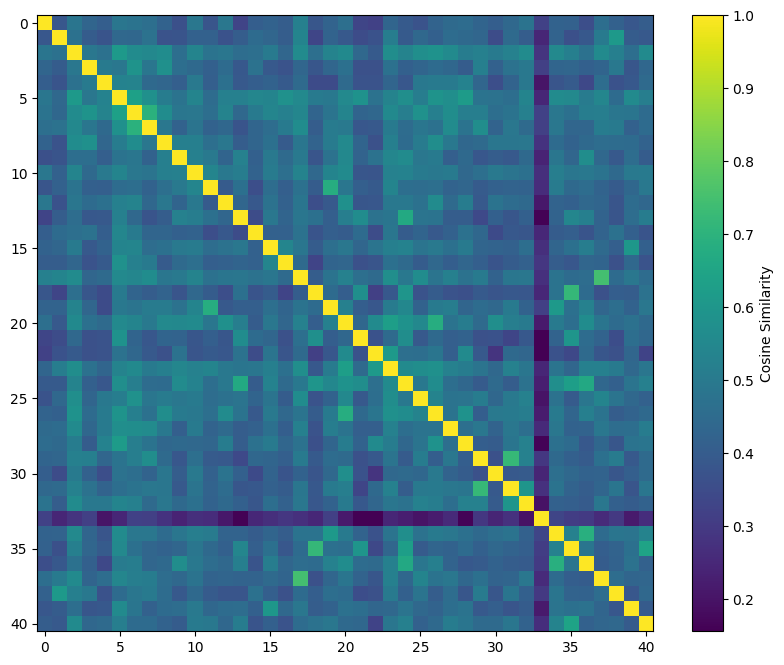

In [49]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Cosine Similarity")